# ================================
# SMS SPAM DETECTION USING NLP
# Member 2 - Naive Bayes & LSTM
# ================================


# 1. IMPORT REQUIRED LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD THE DATASET

In [2]:
# Load the dataset
df = pd.read_csv('sms_spam_collection (1).csv')

# Display the first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3. DATASET EXPLORATION


In [4]:
# Check the number of rows and columns
df.shape

(5572, 2)

In [5]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
# Check for missing values
df.isnull().sum()

,0
label,0
message,0


In [7]:
# Count duplicate rows
df.duplicated().sum()

np.int64(403)

# 4. DATA CLEANING


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new shape
df.shape

(5169, 2)

In [9]:
# Verify duplicates are removed
df.duplicated().sum()

np.int64(0)

In [10]:
# Count Spam and Ham messages
df['label'].value_counts()

,count
label,
ham,4516
spam,653


# 5. EXPLORATORY DATA ANALYSIS (EDA)


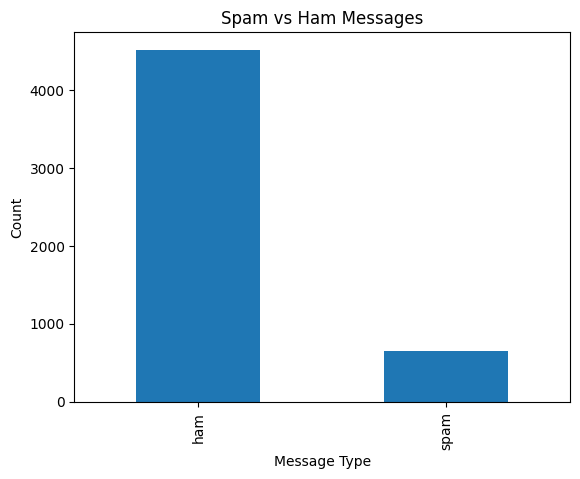

In [11]:
import matplotlib.pyplot as plt

# Bar chart of class distribution
df['label'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

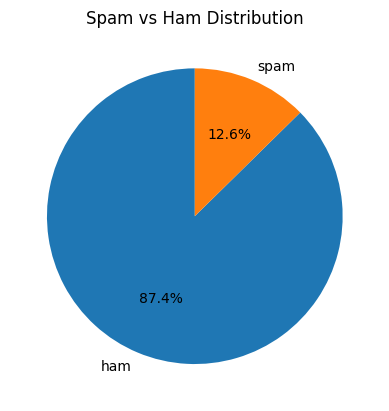

In [12]:
# Pie chart
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Spam vs Ham Distribution')
plt.ylabel('')
plt.show()

In [13]:
# Calculate message length
df['message_length'] = df['message'].apply(len)

# Display first 5 rows
df[['label', 'message_length']].head()

,label,message_length
0,ham,111
1,ham,29
2,spam,155
3,ham,49
4,ham,61


In [14]:
# Summary statistics
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


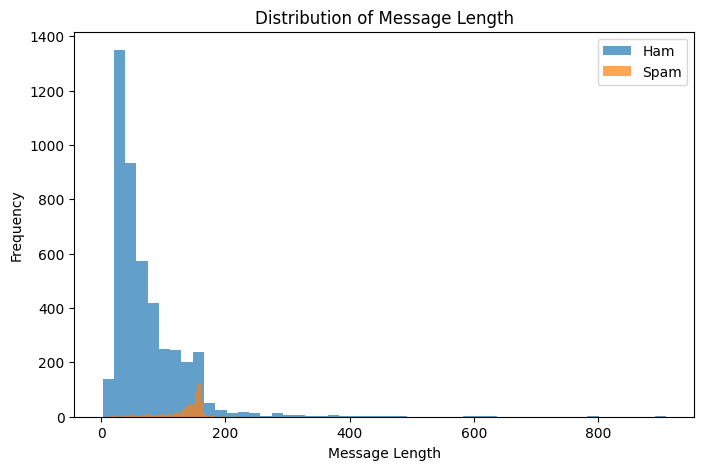

In [15]:
import matplotlib.pyplot as plt

# Histogram of message lengths
plt.figure(figsize=(8,5))

plt.hist(
    df[df['label'] == 'ham']['message_length'],
    bins=50,
    alpha=0.7,
    label='Ham'
)

plt.hist(
    df[df['label'] == 'spam']['message_length'],
    bins=50,
    alpha=0.7,
    label='Spam'
)

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Distribution of Message Length")
plt.legend()

plt.show()

# 6. TEXT PREPROCESSING


In [21]:
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')   # <-- Add this line
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
df['clean_message'] = df['message'].apply(preprocess)

df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


# 7. TF-IDF FEATURE ENGINEERING


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Convert cleaned text into numerical features
X = tfidf.fit_transform(df['clean_message'])

# Labels (Spam/Ham)
y = df['label']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5169, 7905)


# 8. TRAIN-TEST SPLIT (NAIVE BAYES)


In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4135, 7905)
Testing Data : (1034, 7905)


# 9. NAIVE BAYES MODEL


In [25]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [26]:
# Predict on the test data
y_pred = nb_model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

['ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


# 10. NAIVE BAYES MODEL EVALUATION


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred, pos_label='spam')

# Recall
recall = recall_score(y_test, y_pred, pos_label='spam')

# F1 Score
f1 = f1_score(y_test, y_pred, pos_label='spam')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.965183752417795
Precision: 1.0
Recall   : 0.7251908396946565
F1 Score : 0.8407079646017699


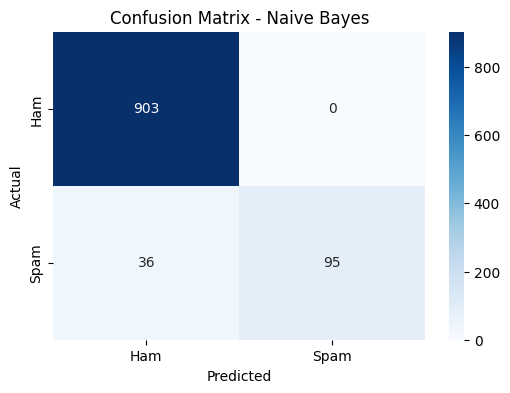

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034



# 11. LSTM DATA PREPARATION


In [30]:
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [31]:
# Encode labels

encoder = LabelEncoder()

y_dl = encoder.fit_transform(df['label'])

print(y_dl[:10])

[0 0 1 0 0 1 0 0 1 1]


In [33]:
# Create tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_message'])

In [34]:
# Convert text into sequences

sequences = tokenizer.texts_to_sequences(df['clean_message'])

print(sequences[:5])

[[6, 3270, 255, 539, 569, 984, 44, 61, 321, 805, 87, 2239, 985, 11, 3271, 70], [9, 210, 1120, 322, 1, 1461], [12, 413, 806, 807, 127, 2240, 879, 540, 2241, 197, 186, 21, 2240, 256, 413, 3272, 37, 3273, 323, 3274], [1, 140, 56, 248, 2242, 1, 76, 73, 56], [746, 7, 36, 6, 691, 104, 120, 338]]


In [35]:
max_length = 100

X_dl = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print(X_dl.shape)

(5169, 100)


In [36]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42,
    stratify=y_dl
)

print(X_train_dl.shape)
print(X_test_dl.shape)

(4135, 100)
(1034, 100)


# 12. BUILD LSTM MODEL


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [38]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=5000,
                    output_dim=64,
                    input_length=100))

# LSTM Layer
model.add(LSTM(64))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [39]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("LSTM model compiled successfully!")

LSTM model compiled successfully!


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.build(input_shape=(None, 100))

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.build(input_shape=(None, 100))

In [63]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,339,717 (8.93 MB)

 Trainable params: 779,905 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,559,812 (5.95 MB)

# 13. TRAIN THE LSTM MODEL


In [64]:
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl),
    verbose=1
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.8738 - loss: 0.3919 - val_accuracy: 0.8733 - val_loss: 0.3801
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.8738 - loss: 0.3938 - val_accuracy: 0.8733 - val_loss: 0.3830
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.8738 - loss: 0.3908 - val_accuracy: 0.8733 - val_loss: 0.3801
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.8738 - loss: 0.3892 - val_accuracy: 0.8733 - val_loss: 0.3801
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - accuracy: 0.8738 - loss: 0.3895 - val_accuracy: 0.8733 - val_loss: 0.3816
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 176ms/step - accuracy: 0.8738 - loss: 0.3870 - val_accuracy: 0.8733 - val_loss: 0.3806
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.8738 - loss: 0.3886 - val_accuracy: 0.8733 - val_loss: 0.3801
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.8738 - loss: 0

# 14. LSTM MODEL EVALUATION


In [65]:
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)

print("Test Accuracy:", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8733 - loss: 0.3801
Test Accuracy: 0.8733075261116028


In [66]:
y_pred_prob = model.predict(X_test_dl)

y_pred_dl = (y_pred_prob > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


In [67]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_dl, y_pred_dl))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       903
           1       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


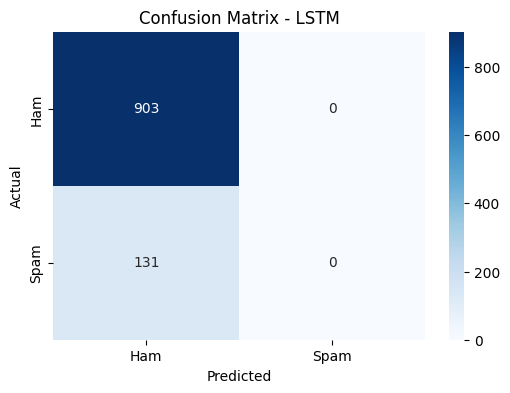

In [68]:
cm = confusion_matrix(y_test_dl, y_pred_dl)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM")

plt.show()

# 15. SAVE THE TRAINED MODELS


In [69]:
import joblib

joblib.dump(nb_model, 'naive_bayes_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Naive Bayes model saved successfully!")

Naive Bayes model saved successfully!


In [70]:
model.save('lstm_model.keras')

print("LSTM model saved successfully!")

LSTM model saved successfully!
